### Uploading and Visualizing the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/fvilacrespo/Stellar-Classification/refs/heads/main/data.csv')

# Check types and structure
display(df.dtypes)
display(df.head())

,0
obj_ID,float64
alpha,float64
delta,float64
u,float64
g,float64
r,float64
i,float64
z,float64
run_ID,int64
rerun_ID,int64


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
# We check if there are any null values or duplicated rows (should ouput 0 everywhere, and it does)
print(df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Duplicated Rows: 0


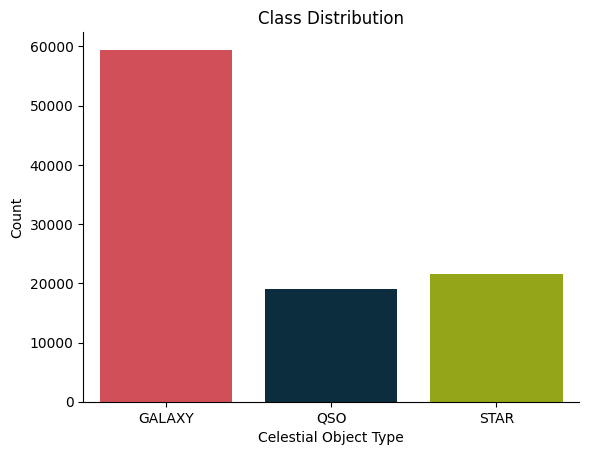

In [ ]:
# Creating a copy to do some visualizations
df_copy = df.copy()
df_copy['u-g'] = df_copy['u'] - df_copy['g']
df_copy['g-r'] = df_copy['g'] - df_copy['r']

# Creating a color palette
custom_palette = {"GALAXY": "#e63946", "STAR": "#a5be00", "QSO": "#023047"}

# Plot 1: Class Distribution
sns.countplot(x='class', data=df_copy, palette=custom_palette, hue='class')
plt.title('Class Distribution')
plt.xlabel('Celestial Object Type')
plt.ylabel('Count')
sns.despine()
plt.savefig('class_distribution_plot.png', bbox_inches='tight', dpi=300)
plt.show()

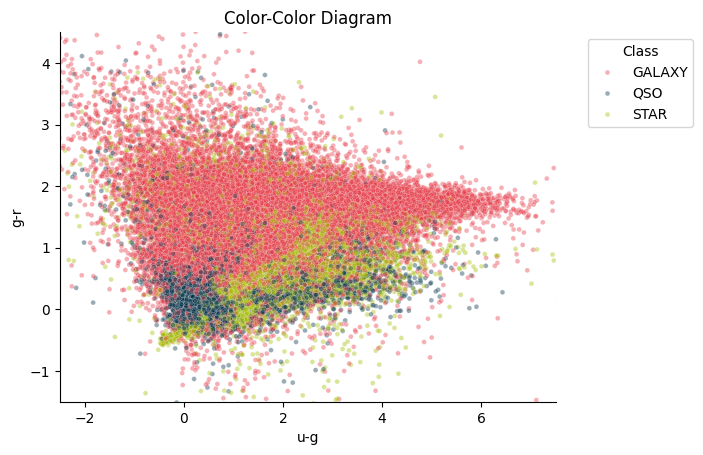

In [ ]:
# Plot 2: Color-Color Diagram
sns.scatterplot(x='u-g', y='g-r', hue='class', data=df_copy, palette=custom_palette, s=12, alpha=0.4)
plt.title('Color-Color Diagram')
plt.xlim([-2.5, 7.5])
plt.ylim([-1.5, 4.5])
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
sns.despine()
plt.savefig('color_indices_plot.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Pre-processing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# the following features are needed to be discarded
discarded_cols = ['alpha', 'delta', 'obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df = df.drop(columns=discarded_cols)

# we add 4 features
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Encoding
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])

# Splitting features
X = df.drop(columns=['class'])
y = df['class']

# Splitting data into train and test sets, with random_state to ensure reproducible results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Implementation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Fitting a Random Forest model on the scaled training set
rf_model = RandomForestClassifier(n_estimators=100, random_state=14)
rf_model.fit(X_train_scaled, y_train)

# Fitting a Logistic Regression Model on the scaled training set
log_model = LogisticRegression(random_state=14, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_log = log_model.predict(X_test_scaled)


### Evaluating the models

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Logistic Regression Classification (without correlation matrix) Report: 
               precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     11859
         QSO       0.95      0.88      0.91      3865
        STAR       0.95      1.00      0.97      4276

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000

Logistic Regression Accuracy: 
 0.956

Logistic Regression Confusion Matrix: 



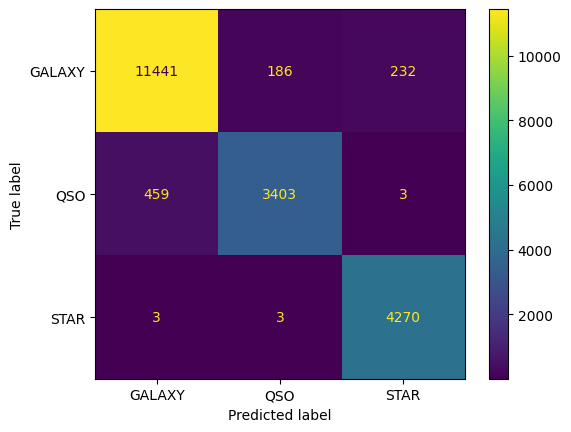

In [ ]:
# Logistic Regression Evaluation (precision, recall, f1-score, accuracy, and then displaying the confusion matrix)
print('Logistic Regression Classification (without correlation matrix) Report: \n', classification_report(y_test, y_pred_log, target_names=encoder.classes_))
print('Logistic Regression Accuracy: \n', round(accuracy_score(y_test, y_pred_log), 3))
print('\nLogistic Regression Confusion Matrix: \n')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, display_labels=encoder.classes_)
plt.show()

Random Forest Classification Report: 
               precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11859
         QSO       0.97      0.94      0.95      3865
        STAR       1.00      1.00      1.00      4276

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Random Forest Accuracy: 
 0.981

Random Forest Confusion Matrix: 



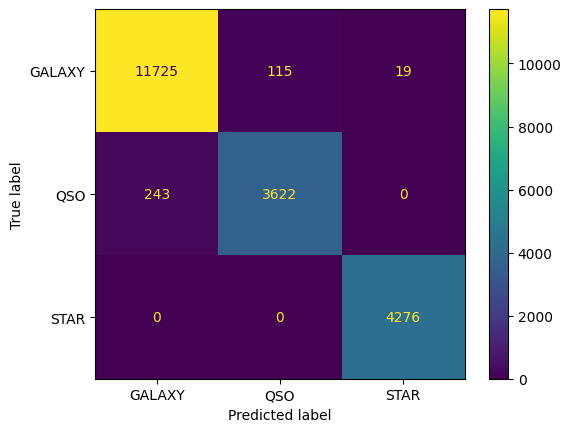

In [ ]:
# Random Forest Evaluation (precision, recall, f1-score, accuracy, and then displaying the confusion matrix)
print('Random Forest Classification Report: \n', classification_report(y_test, y_pred_rf, target_names=encoder.classes_))
print('Random Forest Accuracy: \n', round(accuracy_score(y_test, y_pred_rf), 3))
print('\nRandom Forest Confusion Matrix: \n')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=encoder.classes_)
plt.show()

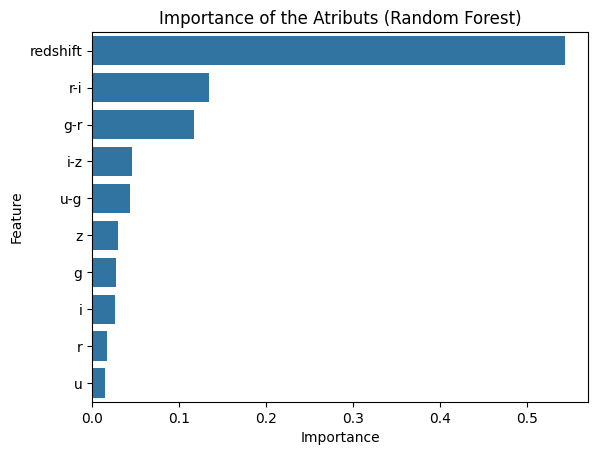

In [ ]:
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance= feature_importance.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Importance of the Atributs (Random Forest)')
plt.savefig('feature_importance_rf.png', bbox_inches='tight', dpi=300)
plt.show()